# 🏗️ Treinamento de Modelos de Regressão - London Houses

Neste notebook, vamos treinar e comparar diferentes modelos de regressão para prever o valor mediano das casas.

## 1. Importações e Configurações

In [1]:
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import mlflow
import mlflow.sklearn

from xgboost import XGBRegressor
import joblib

# Adicionar o diretório src ao path para importar o pipeline de pré-processamento
sys.path.append(os.path.abspath("../src"))
from data.data_processor import build_preprocessing_pipeline

# Configurações de visualização
%matplotlib inline
sns.set_theme(style="whitegrid")
os.makedirs('../models/trained_models', exist_ok=True)

/home/usuario/workdir/ML_portfolio/London_houses/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carregamento e Divisão dos Dados

In [2]:
# Carregar os dados
df = pd.read_csv('../data/housing.csv')

# Separar features e target
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"].copy()

# Dividir treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do treino: {X_train.shape[0]}")
print(f"Tamanho do teste: {X_test.shape[0]}")

Tamanho do treino: 16512
Tamanho do teste: 4128


## 3. Pré-processamento

Vamos usar o pipeline definido em `src/data/data_processor.py`.

In [3]:
preprocessor = build_preprocessing_pipeline()
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Formato dos dados processados:", X_train_prepared.shape)

Formato dos dados processados: (16512, 13)


## 4. Treinamento e Avaliação de Modelos

Vamos criar uma função para treinar e avaliar cada modelo.

In [4]:
def evaluate_model(model, name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    
    print(f"--- {name} ---")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R2 Score: {r2:.4f}")
    return rmse, r2

results = {}

# 1. Linear Regression
results['Linear Regression'] = evaluate_model(LinearRegression(), "Linear Regression", X_train_prepared, y_train, X_test_prepared, y_test)

# 2. Decision Tree
results['Decision Tree'] = evaluate_model(DecisionTreeRegressor(random_state=42), "Decision Tree", X_train_prepared, y_train, X_test_prepared, y_test)

# 3. Random Forest
results['Random Forest'] = evaluate_model(RandomForestRegressor(n_estimators=100, random_state=42), "Random Forest", X_train_prepared, y_train, X_test_prepared, y_test)

# 4. XGBoost
results['XGBoost'] = evaluate_model(XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42), "XGBoost", X_train_prepared, y_train, X_test_prepared, y_test)

--- Linear Regression ---
RMSE: 70,059.19
R2 Score: 0.6254
--- Decision Tree ---
RMSE: 69,175.77
R2 Score: 0.6348
--- Random Forest ---
RMSE: 48,941.70
R2 Score: 0.8172
--- XGBoost ---
RMSE: 48,827.75
R2 Score: 0.8181


## 5. Comparação de Performance

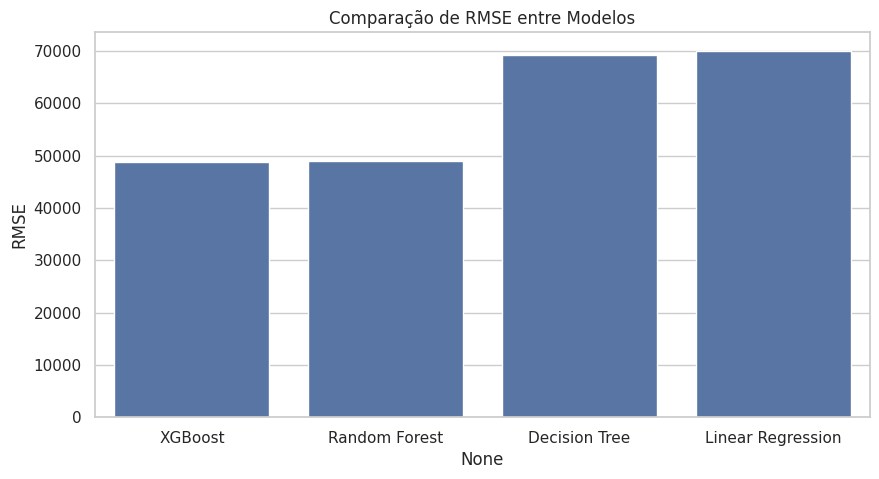

,RMSE,R2 Score
XGBoost,48827.750983,0.818061
Random Forest,48941.700343,0.817210
Decision Tree,69175.769189,0.634825
Linear Regression,70059.193339,0.625438


In [5]:
res_df = pd.DataFrame(results, index=['RMSE', 'R2 Score']).T
res_df = res_df.sort_values(by='RMSE')

plt.figure(figsize=(10, 5))
sns.barplot(x=res_df.index, y=res_df['RMSE'])
plt.title('Comparação de RMSE entre Modelos')
plt.ylabel('RMSE')
plt.show()

res_df

In [6]:
# Definimos um nome para os experimentos do notebook
mlflow.set_experiment("London_Housing_Notebook")

def evaluate_model(model, name, X_train, y_train, X_test, y_test):
    # Inicia um rastreamento no MLflow
    with mlflow.start_run(run_name=f"train_{name.replace(' ', '_')}"):
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        
        mse = mean_squared_error(y_test, predictions)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, predictions)
        
        # Logando os dados no MLflow
        mlflow.log_param("model_type", name)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("r2_score", r2)
        mlflow.sklearn.log_model(model, "model")
        
        print(f"--- {name} ---")
        print(f"RMSE: {rmse:,.2f}")
        print(f"R2 Score: {r2:.4f}")
        return rmse, r2

results = {}

# 1. Linear Regression
results['Linear Regression'] = evaluate_model(LinearRegression(), "Linear Regression", X_train_prepared, y_train, X_test_prepared, y_test)

# 2. Decision Tree
results['Decision Tree'] = evaluate_model(DecisionTreeRegressor(random_state=42), "Decision Tree", X_train_prepared, y_train, X_test_prepared, y_test)

# 3. Random Forest
results['Random Forest'] = evaluate_model(RandomForestRegressor(n_estimators=100, random_state=42), "Random Forest", X_train_prepared, y_train, X_test_prepared, y_test)

# 4. XGBoost
results['XGBoost'] = evaluate_model(XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42), "XGBoost", X_train_prepared, y_train, X_test_prepared, y_test)


2026/04/29 22:31:21 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/29 22:31:21 INFO mlflow.store.db.utils: Updating database tables
2026/04/29 22:31:25 INFO mlflow.tracking.fluent: Experiment with name 'London_Housing_Notebook' does not exist. Creating a new experiment.
2026/04/29 22:31:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 22:31:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/29 22:31:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


--- Linear Regression ---
RMSE: 70,059.19
R2 Score: 0.6254


2026/04/29 22:31:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 22:31:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/29 22:31:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


--- Decision Tree ---
RMSE: 69,175.77
R2 Score: 0.6348


2026/04/29 22:32:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 22:32:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/29 22:32:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


--- Random Forest ---
RMSE: 48,941.70
R2 Score: 0.8172


2026/04/29 22:32:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 22:32:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/29 22:32:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


--- XGBoost ---
RMSE: 48,827.75
R2 Score: 0.8181


## 6. Salvando o Melhor Modelo

O XGBoost ou Random Forest provavelmente será o melhor.

In [ ]:
# Supondo que o XGBoost seja o melhor
best_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
best_model.fit(X_train_prepared, y_train)

joblib.dump(best_model, '../models/trained_models/xgboost_model.pkl')
joblib.dump(preprocessor, '../models/trained_models/preprocessor.pkl')

print("Melhor modelo e preprocessor salvos em ../models/trained_models/")